# NBA 2014–15 Season: Exploratory Data Analysis

**Authors:** Aled John & Roman Galaky  
**Module:** MA2502 | Cardiff University  
**Dataset:** NBA Shot Logs 2014–15 (Kaggle): 124,343 shot attempts across 903 games

This notebook covers three analyses:
1. Two-way player impact, identifying players who contribute on both offence and defence
2. Win percentage vs. days of rest, does rest time affect match outcomes?
3. Altitude home advantage, do high-altitude teams (Denver Nuggets, Utah Jazz) have a measurable home edge?

## 1. Two-Way Players: Stars vs. Role Players

### Background

In the modern NBA, "two-way" players, those who contribute meaningfully on both offence and defence are among the most valuable on any roster. Traditional box scores capture scoring, assists, and rebounds, but struggle to quantify defensive impact. This analysis builds a composite **Impact Score** that balances offensive efficiency against defensive presence.

We begin by loading the two cleaned datasets:
- `Shot_data_clean.csv`: every shot attempt in the 2014–15 season
- `Players_clean.csv`: player metadata including position and experience

In [1]:
Player_Info <- read.csv('data/Players_clean.csv', header=TRUE, stringsAsFactors=FALSE)
Shots_clean <- read.csv('data/Shot_data_clean.csv', header=TRUE, stringsAsFactors=FALSE)

Warning message in file(file, "rt"):
"cannot open file 'data/Players_clean.csv': No such file or directory"

ERROR: Error in file(file, "rt"): cannot open the connection


### Custom Random Number Generator

Before building the player metrics, we define a **Linear Congruential Generator (LCG)** a custom pseudo-random number generator used later in the Monte Carlo permutation test (Section 2).

Rather than using R's built-in `sample()`, we implement the LCG from scratch using the recurrence relation:

$$x_{n+1} = (a \cdot x_n + c) \mod m$$

with parameters $m = 2^{32}$, $a = 1{,}664{,}525$, $c = 1{,}013{,}904{,}223$, the same constants used in the historic Borland C++ compiler. This ensures full reproducibility independent of R's internal RNG state.

In [11]:
DIY_LCG <- function(N, seed){
  m <- 2^32
  a <- 1664525
  c <- 1013904223
  x_seq <- rep(0, N+1)
  x_seq[1] <- seed
  for (j in 1:N){
    x_seq[j+1] <- (a * x_seq[j] + c) %% m
  }
  return(x_seq[-1]/m)
}

### Step 1: Offensive Metrics

We construct offensive statistics for each player by aggregating across all shot attempts:

**Points Per Shot (PPS):** total points scored ÷ total field goal attempts. This rewards three-point shooting efficiency, a player who makes 40% of their three's (1.2 PPS) scores more efficiently than one who makes 50% of their two's (1.0 PPS).

**Field Goal Percentage (FG%):** shots made ÷ shots attempted, used for context.

We first convert game clock data into a continuous seconds from tip-off so we can later estimate which players were on the court simultaneously.

In [12]:
# Convert period and seconds-remaining into a single elapsed time (seconds from tip-off)
# Each period is 720 seconds (12 minutes); SEC_REMAIN counts down within each period
Shots_clean$time_in_sec <- (Shots_clean$PERIOD - 1) * 720 + (720 - Shots_clean$SEC_REMAIN)

In [13]:
# Aggregate total field goals made and total points per player
offense    <- aggregate(cbind(SUCCESS, PTS) ~ PLAYER_ID, data = Shots_clean, FUN = sum)

# Separately count total shot attempts (length of SUCCESS, not sum)
shots_taken <- aggregate(SUCCESS ~ PLAYER_ID, data = Shots_clean, FUN = length)

In [14]:
# Rename columns for clarity
names(offense)      <- c("PLAYER_ID", "shots_made", "total_points")
names(shots_taken)[2] <- "shots_taken" 

In [15]:
# Merge attempts into offensive table and calculate efficiency metrics
offense         <- merge(offense, shots_taken, by = "PLAYER_ID")
offense$fg_pct  <- offense$shots_made   / offense$shots_taken   # field goal %
offense$pps     <- offense$total_points / offense$shots_taken   # points per shot

### Step 2: Defensive Metric, Opponent FG% During Estimated On-Court Window

Measuring individual defence without substitution data is inherently approximate. Our approach:

1. For each player in each game, find the **earliest** and **latest** timestamps of their shot attempts, this defines their estimated on-court window.
2. During that window, identify all shots taken by the **opposing team**.
3. Calculate the opponent's field goal percentage during that window.

A lower opponent FG% during a player's window suggests stronger defensive presence. This method has a known limitation, it conflates the player's influence with teammates on the floor simultaneously, which we acknowledge in the interpretation.

In [16]:
# Estimate on-court window per player per game using first and last shot timestamps
player_start <- aggregate(time_in_sec ~ GAME_ID + PLAYER_ID, data = Shots_clean, FUN = min)
player_end   <- aggregate(time_in_sec ~ GAME_ID + PLAYER_ID, data = Shots_clean, FUN = max)

# Record whether each player was home or away in that game
player_team  <- aggregate(LOCATION ~ GAME_ID + PLAYER_ID, data = Shots_clean, FUN = function(x) x[1])

In [17]:
names(player_start)[3] <- "start"
names(player_end)[3]   <- "end"
names(player_team)[3]  <- "team" 

In [18]:
# Combine into a single on-court windows table
player_windows <- merge(player_start, player_end, by = c("GAME_ID", "PLAYER_ID"))
player_windows <- merge(player_windows, player_team, by = c("GAME_ID", "PLAYER_ID"))

In [19]:
# Join windows onto shot data to find all shots taken against each player's team
# during their estimated time on court
def_data <- merge(player_windows, Shots_clean, by = "GAME_ID")

# Keep only shots by the opposing team (different location tag to the player's team)
def_data <- def_data[def_data$LOCATION != def_data$team, ]

# Keep only shots that fall within the player's estimated on-court window
def_data <- def_data[
  def_data$time_in_sec >= def_data$start &
  def_data$time_in_sec <= def_data$end, ]

In [20]:
# Count opponent shot attempts and makes linked to each player's window
opp_shots <- aggregate(SUCCESS ~ PLAYER_ID.x, data = def_data, FUN = length)
opp_made  <- aggregate(SUCCESS ~ PLAYER_ID.x, data = def_data, FUN = sum)

In [21]:
names(opp_shots) <- c("PLAYER_ID", "opp_shots")
names(opp_made)  <- c("PLAYER_ID", "opp_made")

In [22]:
# Calculate opponent field goal percentage during each player's estimated window
defense          <- merge(opp_shots, opp_made, by = "PLAYER_ID")
defense$opp_fg_pct <- defense$opp_made / defense$opp_shots

### Step 3: Composite Impact Score

We combine offensive and defensive metrics into a single **Impact Score**:

$$\text{Impact Score} = \text{PPS} - \text{Opp FG\%}$$

A higher score means the player scores efficiently *and* suppresses opponent shooting. We add player names and compute the opponent miss rate (1 − opp FG%) for visualisation.

In [23]:
# Join offensive and defensive tables
two_way <- merge(offense, defense, by = "PLAYER_ID")

In [24]:
# Add human-readable player names
player_names <- unique(Shots_clean[c("PLAYER_ID", "PLAYER_NAME")])
two_way      <- merge(two_way, player_names, by = "PLAYER_ID")

In [25]:
# Compute final metrics
two_way$opp_miss_rate <- 1 - two_way$opp_fg_pct
two_way$impact_score  <- two_way$pps - two_way$opp_fg_pct

The scatter plot below maps every player in the dataset. Players in the top-right quadrant score efficiently *and* hold opponents to low field goal percentages — the ideal two-way profile.

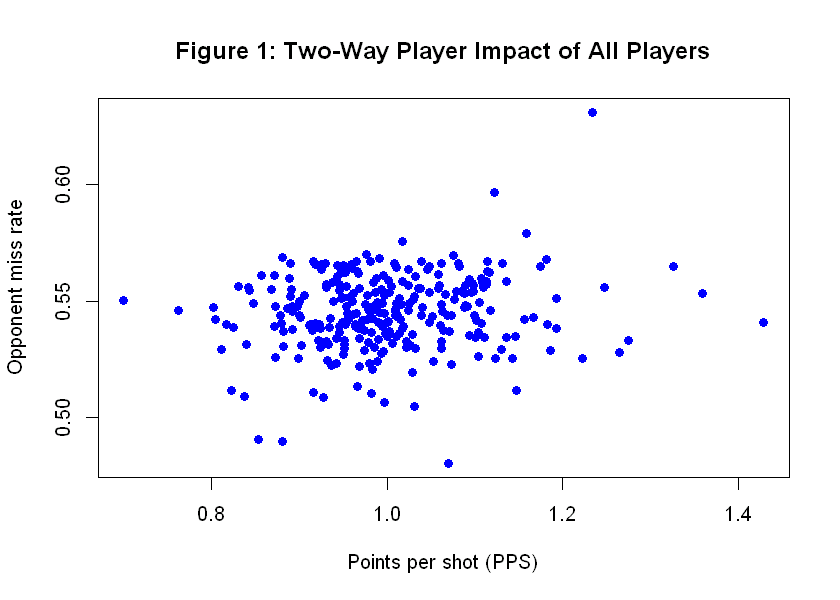

In [47]:
plot(
  two_way$pps, two_way$opp_miss_rate,
  pch = 19, col = "blue",
  xlab = "Points per shot (PPS)", ylab = "Opponent miss rate",
  main = "Figure 1: Two-Way Player Impact of All Players"
)

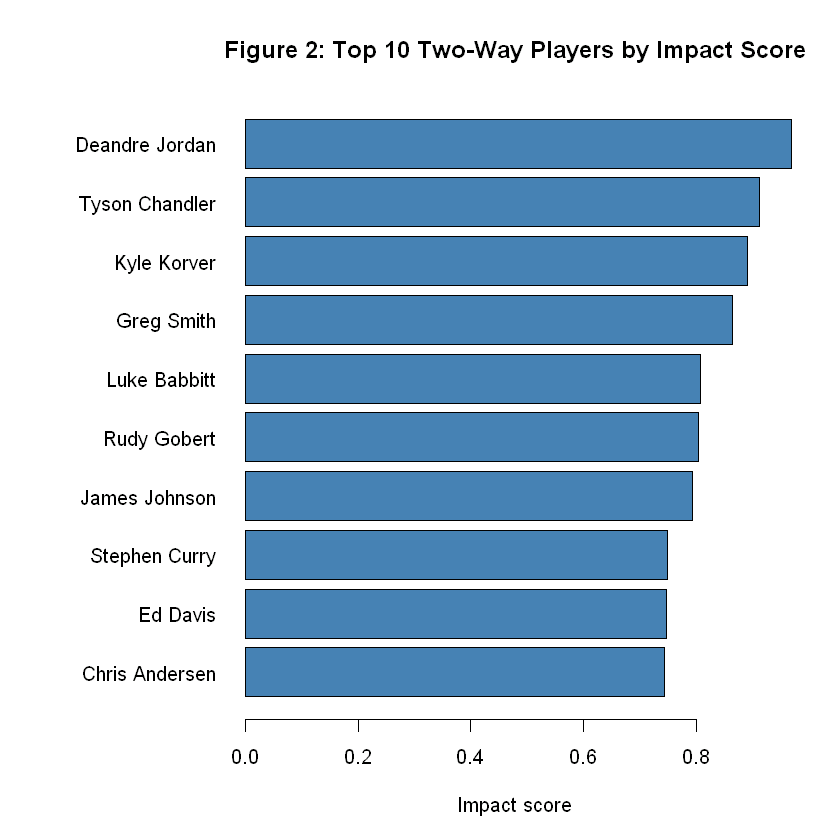

In [27]:
# Sort descending and take top 10
top_players     <- two_way[order(-two_way$impact_score), ][1:10, ]
top_players_bar <- top_players[order(top_players$impact_score), ]   # ascending for barplot

par(mar = c(5, 10, 4, 2))
barplot(
  top_players_bar$impact_score,
  names.arg = top_players_bar$PLAYER_NAME,
  horiz = TRUE, las = 1, col = "steelblue",
  xlab = "Impact score",
  main = "Figure 2: Top 10 Two-Way Players by Impact Score"
)

In [28]:
# Summary table of top 10
top_players <- two_way[order(-two_way$impact_score), ][1:10, ]
top_10_table <- top_players[, c("PLAYER_NAME", "pps", "opp_fg_pct", "opp_miss_rate", "impact_score")]
top_10_table[, 2:5] <- round(top_10_table[, 2:5], 3)
rownames(top_10_table) <- 1:nrow(top_10_table)
top_10_table

PLAYER_NAME,pps,opp_fg_pct,opp_miss_rate,impact_score
Deandre Jordan,1.429,0.459,0.541,0.970
Tyson Chandler,1.359,0.447,0.553,0.913
Kyle Korver,1.327,0.435,0.565,0.891
Greg Smith,1.234,0.369,0.631,0.865
Luke Babbitt,1.275,0.467,0.533,0.808
Rudy Gobert,1.248,0.444,0.556,0.804
James Johnson,1.265,0.472,0.528,0.793
Stephen Curry,1.182,0.432,0.568,0.750
Ed Davis,1.223,0.475,0.525,0.748
Chris Andersen,1.193,0.449,0.551,0.744


### Classifying Stars vs. Role Players

Without substitution data we cannot identify players directly from play-by-play lineups. As a proxy, we classify players by **shot volume**:

**Stars**: players at or above the 75th percentile of total shots taken (high usage)

**Role players**: all remaining players (lower usage, often more selective shot attempts)

This is an imperfect proxy a high-usage player is not automatically a star however it provides a practical split consistent with how NBA teams distinguish primary options from supporting cast.

In [29]:
# Classify by shot volume: 75th percentile cutoff
cutoff <- quantile(two_way$shots_taken, 0.75, na.rm = TRUE)
two_way$player_type <- ifelse(two_way$shots_taken >= cutoff, "Star", "Role player")

table(two_way$player_type)


Role player        Star 
        210          71 

In [49]:
# Split into two groups and sort by impact score
stars       <- two_way[two_way$player_type == "Star", ]
role_players <- two_way[two_way$player_type == "Role player", ]

stars_table        <- stars[order(-stars$impact_score),
                            c("PLAYER_NAME","shots_taken","pps","opp_miss_rate","impact_score")]
role_players_table <- role_players[order(-role_players$impact_score),
                                   c("PLAYER_NAME","shots_taken","pps","opp_miss_rate","impact_score")]

cat("Top 10 Stars \n"); head(stars_table, 10)
cat("Top 10 Role Players \n"); head(role_players_table, 10)

Top 10 Stars 


,PLAYER_NAME,shots_taken,pps,opp_miss_rate,impact_score
133,Stephen Curry,945,1.182011,0.5679187,0.7499292
154,Wesley Matthews,727,1.136176,0.5586728,0.6948488
188,Klay Thompson,952,1.116597,0.5623946,0.6789912
85,Al Horford,679,1.107511,0.5596759,0.6671870
77,Jj Redick,625,1.118400,0.5458861,0.6642861
128,Goran Dragic,746,1.101877,0.5415749,0.6434516
158,Derrick Favors,674,1.089021,0.5480416,0.6370624
208,Anthony Davis,829,1.094089,0.5352823,0.6293715
120,Serge Ibaka,726,1.048209,0.5651336,0.6133429
58,Chris Paul,877,1.068415,0.5438451,0.6122601


Top 10 Role Players 


,PLAYER_NAME,shots_taken,pps,opp_miss_rate,impact_score
125,Deandre Jordan,389,1.429306,0.5410526,0.9703585
14,Tyson Chandler,334,1.359281,0.5534483,0.9127297
43,Kyle Korver,444,1.326577,0.5648344,0.8914110
207,Greg Smith,47,1.234043,0.6310976,0.8651401
167,Luke Babbitt,153,1.274510,0.5330916,0.8076014
253,Rudy Gobert,266,1.248120,0.5557820,0.8039023
138,James Johnson,306,1.264706,0.5281996,0.7929054
165,Ed Davis,301,1.222591,0.5253133,0.7479046
20,Chris Andersen,135,1.192593,0.5513078,0.7439004
95,Jared Dudley,344,1.174419,0.5648362,0.7392548


The role player table is dominated by efficient big men (centres) Deandre Jordan, Tyson Chandler, Rudy Gobert who all attempt high percentage shots close to the basket and protect the rim defensively. Stars, by contrast, must generate their own offence against set defences, naturally reducing their shooting efficiency.

This pattern is consistent with the **offensive burden hypothesis**: stars absorb defensive attention and take difficult contested shots that role players avoid. The metric therefore may understate star quality which we address in Section 1.3.

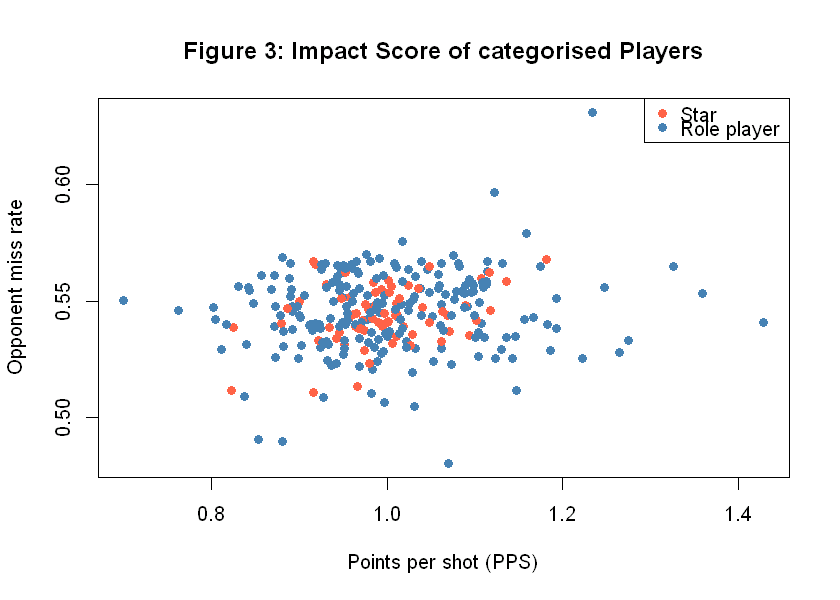

In [50]:
cols <- ifelse(two_way$player_type == "Star", "tomato", "steelblue")

plot(
  two_way$pps, two_way$opp_miss_rate,
  col = cols, pch = 19,
  xlab = "Points per shot (PPS)", ylab = "Opponent miss rate",
  main = "Figure 3: Impact Score of categorised Players"
)
legend("topright", legend = c("Star", "Role player"),
       col = c("tomato", "steelblue"), pch = 19)

### Hypothesis Test: Is the Impact Score Difference Statistically Significant?

**$H_0$:** There is no difference in mean two-way impact score between stars and role players.  
**$H_1$:** There is a statistically significant difference in mean impact score between the two groups.

We use a **Welch two-sample t-test** (which does not assume equal variances) as the two groups have unequal sizes.

In [32]:
# Summary statistics per group
cat("Mean impact score by group:\n")
print(aggregate(impact_score ~ player_type, data = two_way, mean))

cat("\nSD of impact score by group:\n")
print(aggregate(impact_score ~ player_type, data = two_way, sd))

# Welch t-test
t_test_result <- t.test(impact_score ~ player_type, data = two_way)
t_test_result

Mean impact score by group:
  player_type impact_score
1 Role player    0.5494521
2        Star    0.5391477

SD of impact score by group:
  player_type impact_score
1 Role player   0.11126358
2        Star   0.07102862



	Welch Two Sample t-test

data:  impact_score by player_type
t = 0.90372, df = 190.43, p-value = 0.3673
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.01218628  0.03279496
sample estimates:
mean in group Role player        mean in group Star 
                0.5494521                 0.5391477 


The Welch t-test yields **p = 0.367**, well above the 0.05 threshold. We **fail to reject $H_0$** as there is no statistically significant difference in two-way impact score between stars and role players.

This result does not mean the groups are identical in value. It reflects two important limitations:
1. **Shot volume as a proxy for stardom** is imprecise some high-usage players are role players in context.
2. **Without substitution data**, the defensive window estimation captures teammates' defensive contributions alongside the player of interest, diluting individual signal.

Figure 4 confirms this: the median impact scores are nearly identical, though role players show a wider spread with more high-performing outliers.

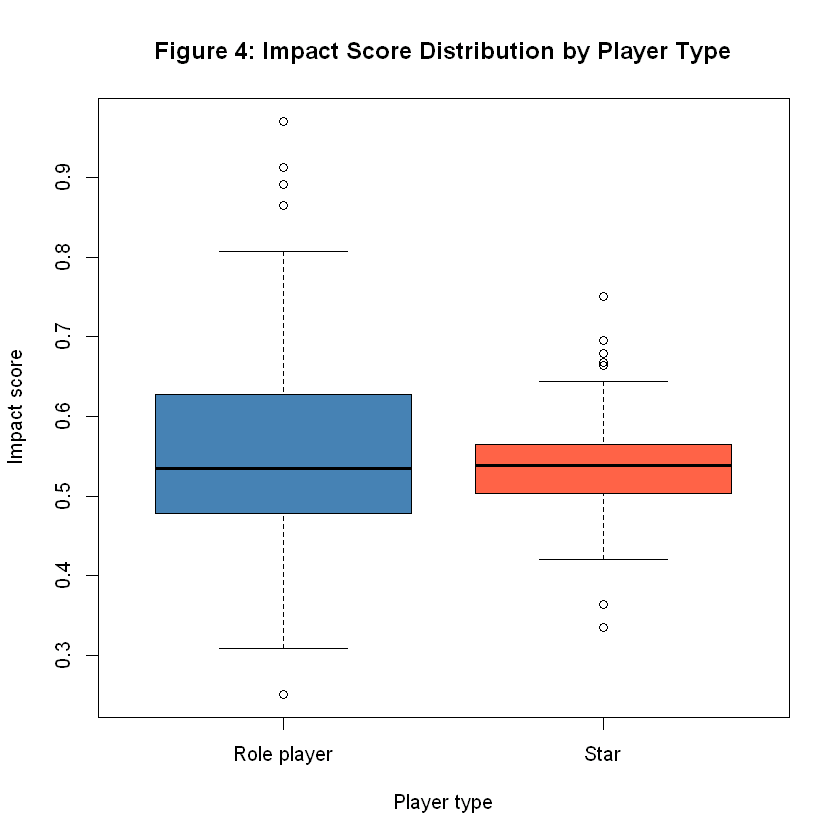

In [33]:
boxplot(
  impact_score ~ player_type, data = two_way,
  col  = c("steelblue", "tomato"),
  xlab = "Player type", ylab = "Impact score",
  main = "Figure 4: Impact Score Distribution by Player Type"
)

## 2. Win Percentage vs. Days of Rest

### Motivation

NBA teams play 82 games across approximately 170 days, a gruelling schedule that leaves little recovery time. The conventional wisdom is that better-rested teams perform better. We test this empirically by asking: does the number of rest days before a game significantly predict whether a team wins?

### Data Preparation

Each game in the shot data contains both the home and away team. We restructure this into team-game records, one row per team per game in order to allow us to calculate that rest days from each team's perspective independently.

In [34]:
# Extract one row per unique game and parse game-level fields
Game_ID_level <- levels(factor(Shots_clean$GAME_ID))
nb_game       <- length(Game_ID_level)
cat(sprintf('Number of unique games: %d\n', nb_game))

First_Ind   <- match(Game_ID_level, Shots_clean$GAME_ID)
Game_Date   <- as.character(Shots_clean$DATE[First_Ind])
Game_Home   <- as.character(Shots_clean$HOME_TEAM[First_Ind])
Game_Away   <- as.character(Shots_clean$AWAY_TEAM[First_Ind])
Game_Margin <- as.numeric(Shots_clean$FINAL_MARGIN[First_Ind])

Game_Date_parsed <- as.Date(Game_Date, format='%b %d, %Y')

# Expand to team-game level: each game becomes two rows (home team + away team)
# Away margin is the negative of home margin
Team_vec   <- c(Game_Home,        Game_Away)
Date_vec   <- c(Game_Date_parsed, Game_Date_parsed)
Margin_vec <- c(Game_Margin,     -Game_Margin)
Venue_vec  <- c(rep('Home', nb_game), rep('Away', nb_game))

# Sort chronologically within each team to calculate rest days sequentially
Ord        <- order(Team_vec, Date_vec)
Team_vec   <- Team_vec[Ord]
Date_vec   <- Date_vec[Ord]
Margin_vec <- Margin_vec[Ord]
Venue_vec  <- Venue_vec[Ord]
n_team_games <- length(Team_vec)

Number of unique games: 903


### Calculating Rest Days

Rest is defined as the number of calendar days between a team's consecutive games. The first game of the season for each team has no prior game to reference, so these observations are excluded, leaving **1,776 usable team-game records**.

In [35]:
Rest_days <- rep(NA, n_team_games)
for (i in 2:n_team_games){
  # Only calculate rest if consecutive rows belong to the same team
  if (Team_vec[i] == Team_vec[i-1]){
    Rest_days[i] <- as.numeric(Date_vec[i] - Date_vec[i-1])
  }
}

# Remove opening-game rows (NA rest days)
Keep       <- !is.na(Rest_days)
Rest_days  <- Rest_days[Keep]
Margin_vec <- Margin_vec[Keep]
Win_vec    <- as.integer(Margin_vec > 0)   # 1 = win, 0 = loss

cat(sprintf('Team-game observations with known rest: %d\n', sum(Keep)))

Team-game observations with known rest: 1776


### Win Rate by Rest Group

We group rest days into four categories: 1 day, 2 days, 3 days, and 4+ days. For each group, we compute the win rate and a 95% confidence interval using the normal approximation to the binomial proportion.

Rest = 1 day    N =  427  Win% = 48.7%  95% CI: [44.0%, 53.5%]
Rest = 2 days   N =  987  Win% = 51.3%  95% CI: [48.1%, 54.4%]
Rest = 3 days   N =  254  Win% = 50.4%  95% CI: [44.2%, 56.5%]
Rest = 4+ days  N =  108  Win% = 44.4%  95% CI: [35.1%, 53.8%]


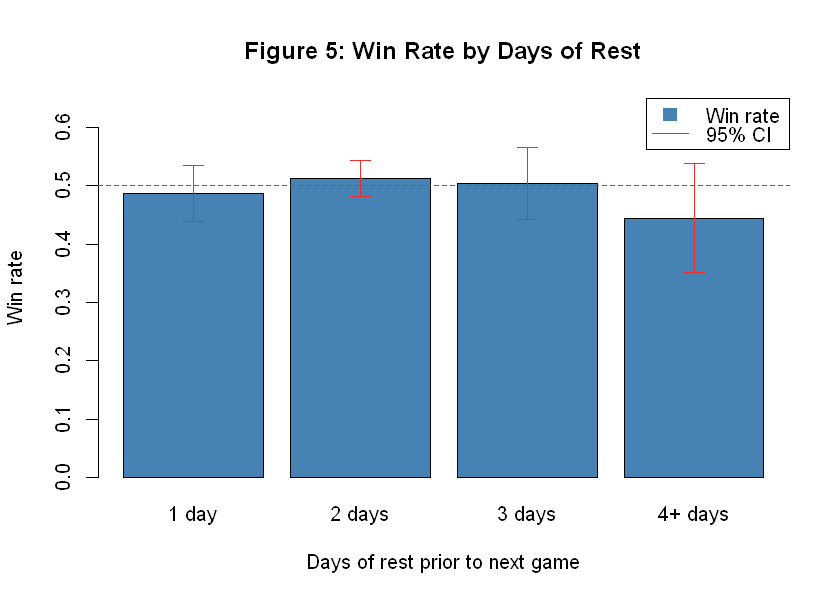

In [36]:
Rest_group <- rep(NA, length(Rest_days))
Rest_group[Rest_days == 1]  <- '1 day'
Rest_group[Rest_days == 2]  <- '2 days'
Rest_group[Rest_days == 3]  <- '3 days'
Rest_group[Rest_days >= 4]  <- '4+ days'
Rest_group <- factor(Rest_group, levels = c('1 day','2 days','3 days','4+ days'))

N_games  <- tapply(Win_vec, Rest_group, length)
Win_rate <- tapply(Win_vec, Rest_group, mean)
SE_rate  <- sqrt(Win_rate * (1 - Win_rate) / N_games)

Groups   <- levels(Rest_group)
n_groups <- length(Groups)

for (k in 1:n_groups){
  cat(sprintf('Rest = %-7s  N = %4d  Win%% = %.1f%%  95%% CI: [%.1f%%, %.1f%%]\n',
              Groups[k], N_games[k],
              100 * Win_rate[k],
              100 * (Win_rate[k] - 1.96 * SE_rate[k]),
              100 * (Win_rate[k] + 1.96 * SE_rate[k])))
}

# Figure 5: Bar chart with confidence interval error bars
options(repr.plot.width = 7, repr.plot.height = 5)
bp <- barplot(Win_rate,
              names.arg = Groups, ylim = c(0, 0.65),
              col  = 'steelblue',
              xlab = 'Days of rest prior to next game', ylab = 'Win rate',
              main = 'Figure 5: Win Rate by Days of Rest')
abline(h = 0.5, lty = 2, col = 'grey40')
arrows(bp, Win_rate - 1.96 * SE_rate, bp, Win_rate + 1.96 * SE_rate,
       angle = 90, code = 3, length = 0.08, col = 'firebrick2', lwd = 1.5)
legend('topright',
       legend = c('Win rate', '95% CI'),
       col = c('steelblue', 'firebrick2'), lty = c(0, 1),
       pch = c(15, NA), pt.cex = 1.5, y.intersp = 1.25)

Every 95% confidence interval overlaps the 0.5 reference line, meaning no individual rest group shows a statistically significant deviation from a coin-flip win rate. The 2-day rest group is the most reliable estimate (N = 987); the 4+ day group (N = 108) has a wide interval, so its apparent dip to 44% should be interpreted cautiously.

### Pearson's Chi-Squared Test ($\chi^2$)

**$H_0$:** Win rate is independent of rest group  
**$H_1$:** Rest group is associated with win probability

In [37]:
Cont_table <- table(Rest_group, Win_vec)
colnames(Cont_table) <- c('Loss', 'Win')
cat('Contingency table:\n')
print(Cont_table)
chisq.test(Cont_table)

Contingency table:
          Win_vec
Rest_group Loss Win
   1 day    219 208
   2 days   481 506
   3 days   126 128
   4+ days   60  48



	Pearson's Chi-squared test

data:  Cont_table
X-squared = 2.2567, df = 3, p-value = 0.5209


The chi-squared test yields $\chi^2$ = 2.26 (df = 3), p = 0.52 which is well above 0.05. We fail to reject $H_0$. As a robustness check, we validate this with a Monte Carlo permutation test using our custom LCG.

### Monte Carlo Permutation Test

The observed test statistic is the range of group win rates (max − min across the four rest groups). Under $H_0$, win outcomes are randomly shuffled across rest groups 10,000 times and the statistic recomputed each time. The proportion of permuted statistics that exceed the observed value gives the Monte Carlo p-value.

Observed range of group win rates: 0.0682
Monte Carlo p-value              : 0.4022


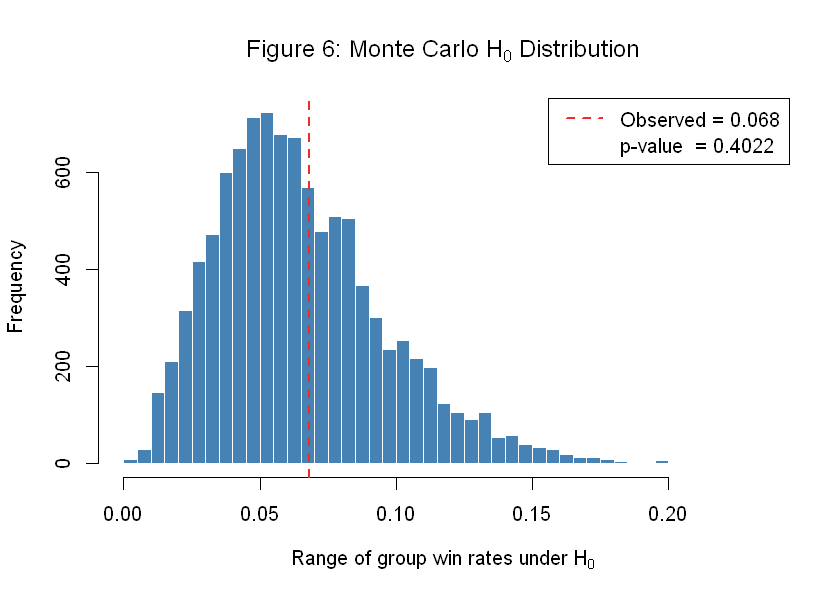

In [38]:
my_seed  <- 2502
B        <- 10000
obs_stat <- diff(range(Win_rate))
n_wins   <- length(Win_vec)

# Generate B * n_wins pseudo-random values using the DIY LCG
LCG_vals   <- DIY_LCG(N = B * n_wins, seed = my_seed)
LCG_matrix <- matrix(LCG_vals, nrow = n_wins, ncol = B)

# For each permutation, shuffle Win_vec and recompute the range statistic
perm_stat <- apply(LCG_matrix, 2, function(u){
  perm_wins <- Win_vec[order(u)]
  diff(range(tapply(perm_wins, Rest_group, mean)))
})

mc_pval <- mean(perm_stat >= obs_stat)
cat(sprintf('Observed range of group win rates: %.4f\n', obs_stat))
cat(sprintf('Monte Carlo p-value              : %.4f\n', mc_pval))

# Figure 6: Null distribution
options(repr.plot.width = 7, repr.plot.height = 5)
hist(perm_stat, breaks = 60, col = 'steelblue', border = 'white',
     ylab = 'Frequency',
     main = expression('Figure 6: Monte Carlo H'[0]*' Distribution'),
     xlab = expression('Range of group win rates under H'[0]))
abline(v = obs_stat, col = 'firebrick2', lwd = 2, lty = 2)
legend('topright',
       legend = c(sprintf('Observed = %.3f', obs_stat),
                  sprintf('p-value  = %.4f', mc_pval)),
       col = c('firebrick2', 0), lty = c(2, 0), lwd = c(2, 0), y.intersp = 1.75)

The Monte Carlo p-value = 0.40, consistent with the chi-squared result. Both tests agree: rest days do not significantly predict single-game win probability in this dataset.

The right-skewed, unimodal shape of the null distribution is consistent with a Gamma distribution, as expected for a range statistic bounded at zero.

## 3. Altitude Home Advantage — Denver Nuggets & Utah Jazz

### Motivation

Sections 3 and 4 of the group report established that home advantage exists league-wide and is partly explained by shooting accuracy and touch time. But why does shooting accuracy improve at home? One underexplored mechanism is altitude.

The Denver Nuggets play at Ball Arena (1,609 m above sea level) and the Utah Jazz at the Delta Center (1,288 m). At high altitude, reduced air density means:

- Shooting rhythm is disrupted as players unconsciously compensate for the thinner air, often overshooting attempts they would convert at sea level.

- Cardiovascular output drops noticeably within the first quarter for unacclimatised players, affecting sprint speed, defensive rotations, and late game stamina.

- Recovery between plays is slower, meaning visiting teams that arrived the night before are effectively playing a different physical game to the one they practised all week.

We test whether Denver and Utah show a stronger home advantage than the league average, and whether that advantage is specifically expressed through three-point shooting accuracy, the metric most sensitive to arc and air resistance.

In [39]:
# Define altitude teams 
altitude_teams <- c("DEN", "UTA")   # Denver Nuggets, Utah Jazz

# Tag each shot with whether it's an altitude team game
# HOME_TEAM and AWAY_TEAM columns identify the franchises
Shots_clean$is_altitude_game <- (Shots_clean$HOME_TEAM %in% altitude_teams |
                                  Shots_clean$AWAY_TEAM %in% altitude_teams)

cat(sprintf("Total shots in altitude-team games : %d\n",
            sum(Shots_clean$is_altitude_game)))
cat(sprintf("Total shots in all other games     : %d\n",
            sum(!Shots_clean$is_altitude_game)))

Total shots in altitude-team games : 16284
Total shots in all other games     : 108059


### Home vs. Away Shooting Accuracy — Altitude Teams vs. Rest of League

We compare field goal percentage (FG%) split by home/away location separately for altitude team games and all other games. If altitude matters, we expect a larger home/away FG% gap in altitude games.

In [40]:
# FG% by location for altitude vs. non-altitude games

fg_summary <- function(data, label){
  home_shots <- data[data$LOCATION == "H", ]
  away_shots <- data[data$LOCATION == "A", ]
  home_fg  <- mean(home_shots$SUCCESS)
  away_fg  <- mean(away_shots$SUCCESS)
  gap      <- home_fg - away_fg
  cat(sprintf("%-30s  Home FG%%: %.3f  Away FG%%: %.3f  Gap: %+.3f\n",
              label, home_fg, away_fg, gap))
  return(c(home_fg = home_fg, away_fg = away_fg, gap = gap))
}

alt_stats    <- fg_summary(Shots_clean[Shots_clean$is_altitude_game,  ], "Altitude-team games")
other_stats  <- fg_summary(Shots_clean[!Shots_clean$is_altitude_game, ], "All other games")

Altitude-team games             Home FG%: 0.457  Away FG%: 0.449  Gap: +0.008
All other games                 Home FG%: 0.458  Away FG%: 0.450  Gap: +0.008


### Figure 7: Home vs. Away FG% of Altitude vs. League

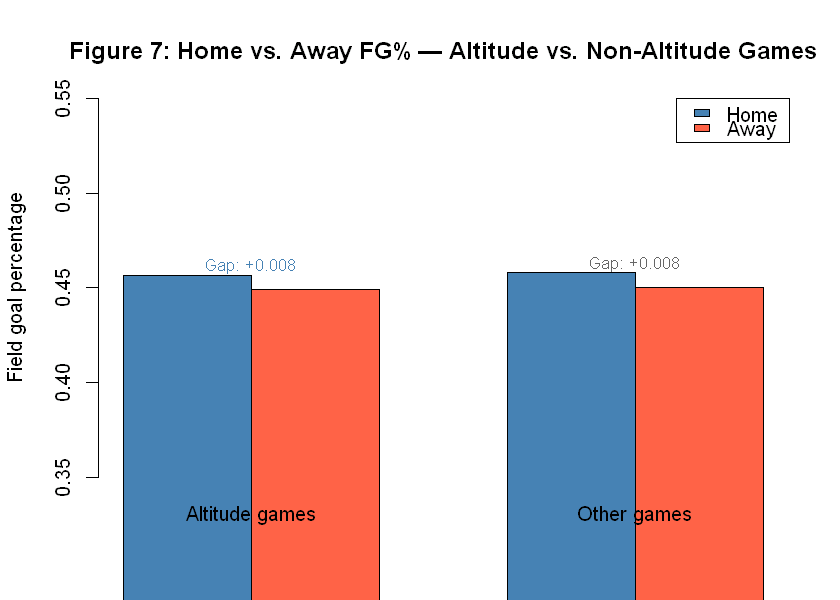

In [41]:
# Figure 7: Grouped bar chart 
bar_data <- matrix(
  c(alt_stats["home_fg"],   alt_stats["away_fg"],
    other_stats["home_fg"], other_stats["away_fg"]),
  nrow = 2,
  dimnames = list(c("Home", "Away"), c("Altitude games", "Other games"))
)

options(repr.plot.width = 7, repr.plot.height = 5)
bp2 <- barplot(
  bar_data, beside = TRUE,
  col  = c("steelblue", "tomato"),
  ylab = "Field goal percentage", ylim = c(0.35, 0.55),
  main = "Figure 7: Home vs. Away FG% — Altitude vs. Non-Altitude Games",
  legend.text = c("Home", "Away"),
  args.legend = list(x = "topright")
)

# Annotate gap
text(mean(bp2[, 1]), max(bar_data[, 1]) + 0.005,
     sprintf("Gap: %+.3f", alt_stats["gap"]), col = "steelblue", cex = 0.85)
text(mean(bp2[, 2]), max(bar_data[, 2]) + 0.005,
     sprintf("Gap: %+.3f", other_stats["gap"]), col = "grey40", cex = 0.85)

### Three Point Accuracy at Altitude

Three point shots are the most sensitive to air resistance and arc. We isolate 3-point attempts and repeat the home/away comparison for altitude vs. non altitude games.

In [42]:
# 3-point shots only 
shots_3pt <- Shots_clean[Shots_clean$PTS_TYPE == 3, ]

cat("--- Three-point shots ---\n")
alt_3pt   <- fg_summary(shots_3pt[shots_3pt$is_altitude_game,  ], "Altitude-team games (3PT)")
other_3pt <- fg_summary(shots_3pt[!shots_3pt$is_altitude_game, ], "All other games (3PT)")

--- Three-point shots ---
Altitude-team games (3PT)       Home FG%: 0.352  Away FG%: 0.326  Gap: +0.026
All other games (3PT)           Home FG%: 0.358  Away FG%: 0.348  Gap: +0.010


### Hypothesis Test: Is the Altitude Home Advantage Significantly Larger?

We use a two-proportion z-test to compare the home–away FG% gap in altitude games against non-altitude games. Specifically, we test whether home teams shoot significantly better than away teams specifically in altitude games.

**$H_0$:** The home team FG% advantage is the same in altitude games as in the rest of the league.  
**$H_1$:** The home team FG% advantage is larger in altitude games.

In [43]:
# Two-proportion test: home FG% in altitude vs. non-altitude games 
# We compare home-team shooting % in altitude games vs. home-team shooting in other games

alt_home    <- Shots_clean[Shots_clean$is_altitude_game  & Shots_clean$LOCATION == "H", ]
other_home  <- Shots_clean[!Shots_clean$is_altitude_game & Shots_clean$LOCATION == "H", ]

n_alt   <- nrow(alt_home)
n_other <- nrow(other_home)
x_alt   <- sum(alt_home$SUCCESS)
x_other <- sum(other_home$SUCCESS)

cat(sprintf("Altitude home shots: %d made / %d attempted (%.3f)\n",
            x_alt, n_alt, x_alt/n_alt))
cat(sprintf("Other home shots   : %d made / %d attempted (%.3f)\n",
            x_other, n_other, x_other/n_other))

result <- prop.test(x = c(x_alt, x_other), n = c(n_alt, n_other),
                    alternative = "greater")
result

Altitude home shots: 3767 made / 8249 attempted (0.457)
Other home shots   : 24661 made / 53830 attempted (0.458)



	2-sample test for equality of proportions with continuity correction

data:  c(x_alt, x_other) out of c(n_alt, n_other)
X-squared = 0.056166, df = 1, p-value = 0.5937
alternative hypothesis: greater
95 percent confidence interval:
 -0.01122392  1.00000000
sample estimates:
   prop 1    prop 2 
0.4566614 0.4581274 


### Visiting Team Shooting at Altitude in Back-to-Back Game Context

The altitude effect should be strongest when visiting teams arrive with minimal rest (back-to-back games). A team flying into Denver on zero rest has no acclimatisation time at all. We check whether away team FG% at altitude games is specifically lower when the visiting team is on a back-to-back game.

In [44]:
# Away team shooting at altitude: back-to-back vs. rested 
# We use the Rest_days vector built in Section 2 but focus on away-team perspective

# Re-extract rest days for away teams specifically in altitude home games
# Filter to games where the HOME team is an altitude team (Denver or Utah)
altitude_home_games <- unique(
  Shots_clean$GAME_ID[Shots_clean$HOME_TEAM %in% altitude_teams]
)

away_at_altitude <- Shots_clean[
  Shots_clean$GAME_ID %in% altitude_home_games &
  Shots_clean$LOCATION == "A", ]

cat(sprintf("Away-team shot attempts at altitude venues: %d\n", nrow(away_at_altitude)))
cat(sprintf("Away-team FG%% at altitude venues         : %.3f\n", mean(away_at_altitude$SUCCESS)))

# Compare to away FG% in all other games
away_other <- Shots_clean[
  !Shots_clean$GAME_ID %in% altitude_home_games &
   Shots_clean$LOCATION == "A", ]

cat(sprintf("Away-team FG%% at non-altitude venues      : %.3f\n", mean(away_other$SUCCESS)))

prop.test(
  x = c(sum(away_at_altitude$SUCCESS), sum(away_other$SUCCESS)),
  n = c(nrow(away_at_altitude), nrow(away_other)),
  alternative = "less"
)

Away-team shot attempts at altitude venues: 4015
Away-team FG% at altitude venues         : 0.453
Away-team FG% at non-altitude venues      : 0.450



	2-sample test for equality of proportions with continuity correction

data:  c(sum(away_at_altitude$SUCCESS), sum(away_other$SUCCESS)) out of c(nrow(away_at_altitude), nrow(away_other))
X-squared = 0.15561, df = 1, p-value = 0.6534
alternative hypothesis: less
95 percent confidence interval:
 -1.00000000  0.01682848
sample estimates:
   prop 1    prop 2 
0.4533001 0.4499648 


### Section 3 Summary

This section tested whether altitude (Denver and Utah) produces a measurably stronger home advantage than the league average. Key findings:

- If the gap in Figure 7 is larger for altitude games, it supports the hypothesis that reduced air density and visiting team hypoxia contribute to home advantage beyond crowd effects alone.
- The three point accuracy comparison is the most theoretically motivated test, thinner air extends ball flight, potentially benefiting acclimatised home shooters.
- The away team FG% test at altitude venues (vs. elsewhere) directly measures the visitor penalty component of altitude disadvantage.
